In [1]:
import numpy as np
import pandas as pd

from experiments import utils
from package_name.training.utils import sampling
from package_name.training.vae import VAE, VAEConfig
from package_name.tuning.cross_validator import CrossValidator

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
filepath = "results/cmmvae/"
cluster_number = 7
original_dim = 825
pr_cluster_number = 5
batch_size = 128
epochs = 150


## Data pre-processing

In [3]:
# Get training data
z500 = utils.preprocess_dataset(filename ='data/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'new atlantic',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('data/CHIRPS_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']
pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Define model

In [4]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_r=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=15,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAE(cfg=config,  path_for_weights_initialization=filepath)
vae.compile()
history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 365.8418 - val_loss: 234.8376
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 199.0929 - val_loss: 164.0833
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 142.9998 - val_loss: 134.1213
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 128.4524 - val_loss: 123.2709
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 115.9869 - val_loss: 109.8074
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 104.7865 - val_loss: 103.5589
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 100.0898 - val_loss: 99.6599
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 95.4719 - val_loss: 93.4367
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 88.1341 - val_loss: 86.6949
Epoch 10/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.2261 - val_loss: 82.5316
Epoch 11/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 80.0367 - val_loss: 80.2402
Epoch 12/150
35/35 ━━━━━━━━━

## Plot training and validation losses.

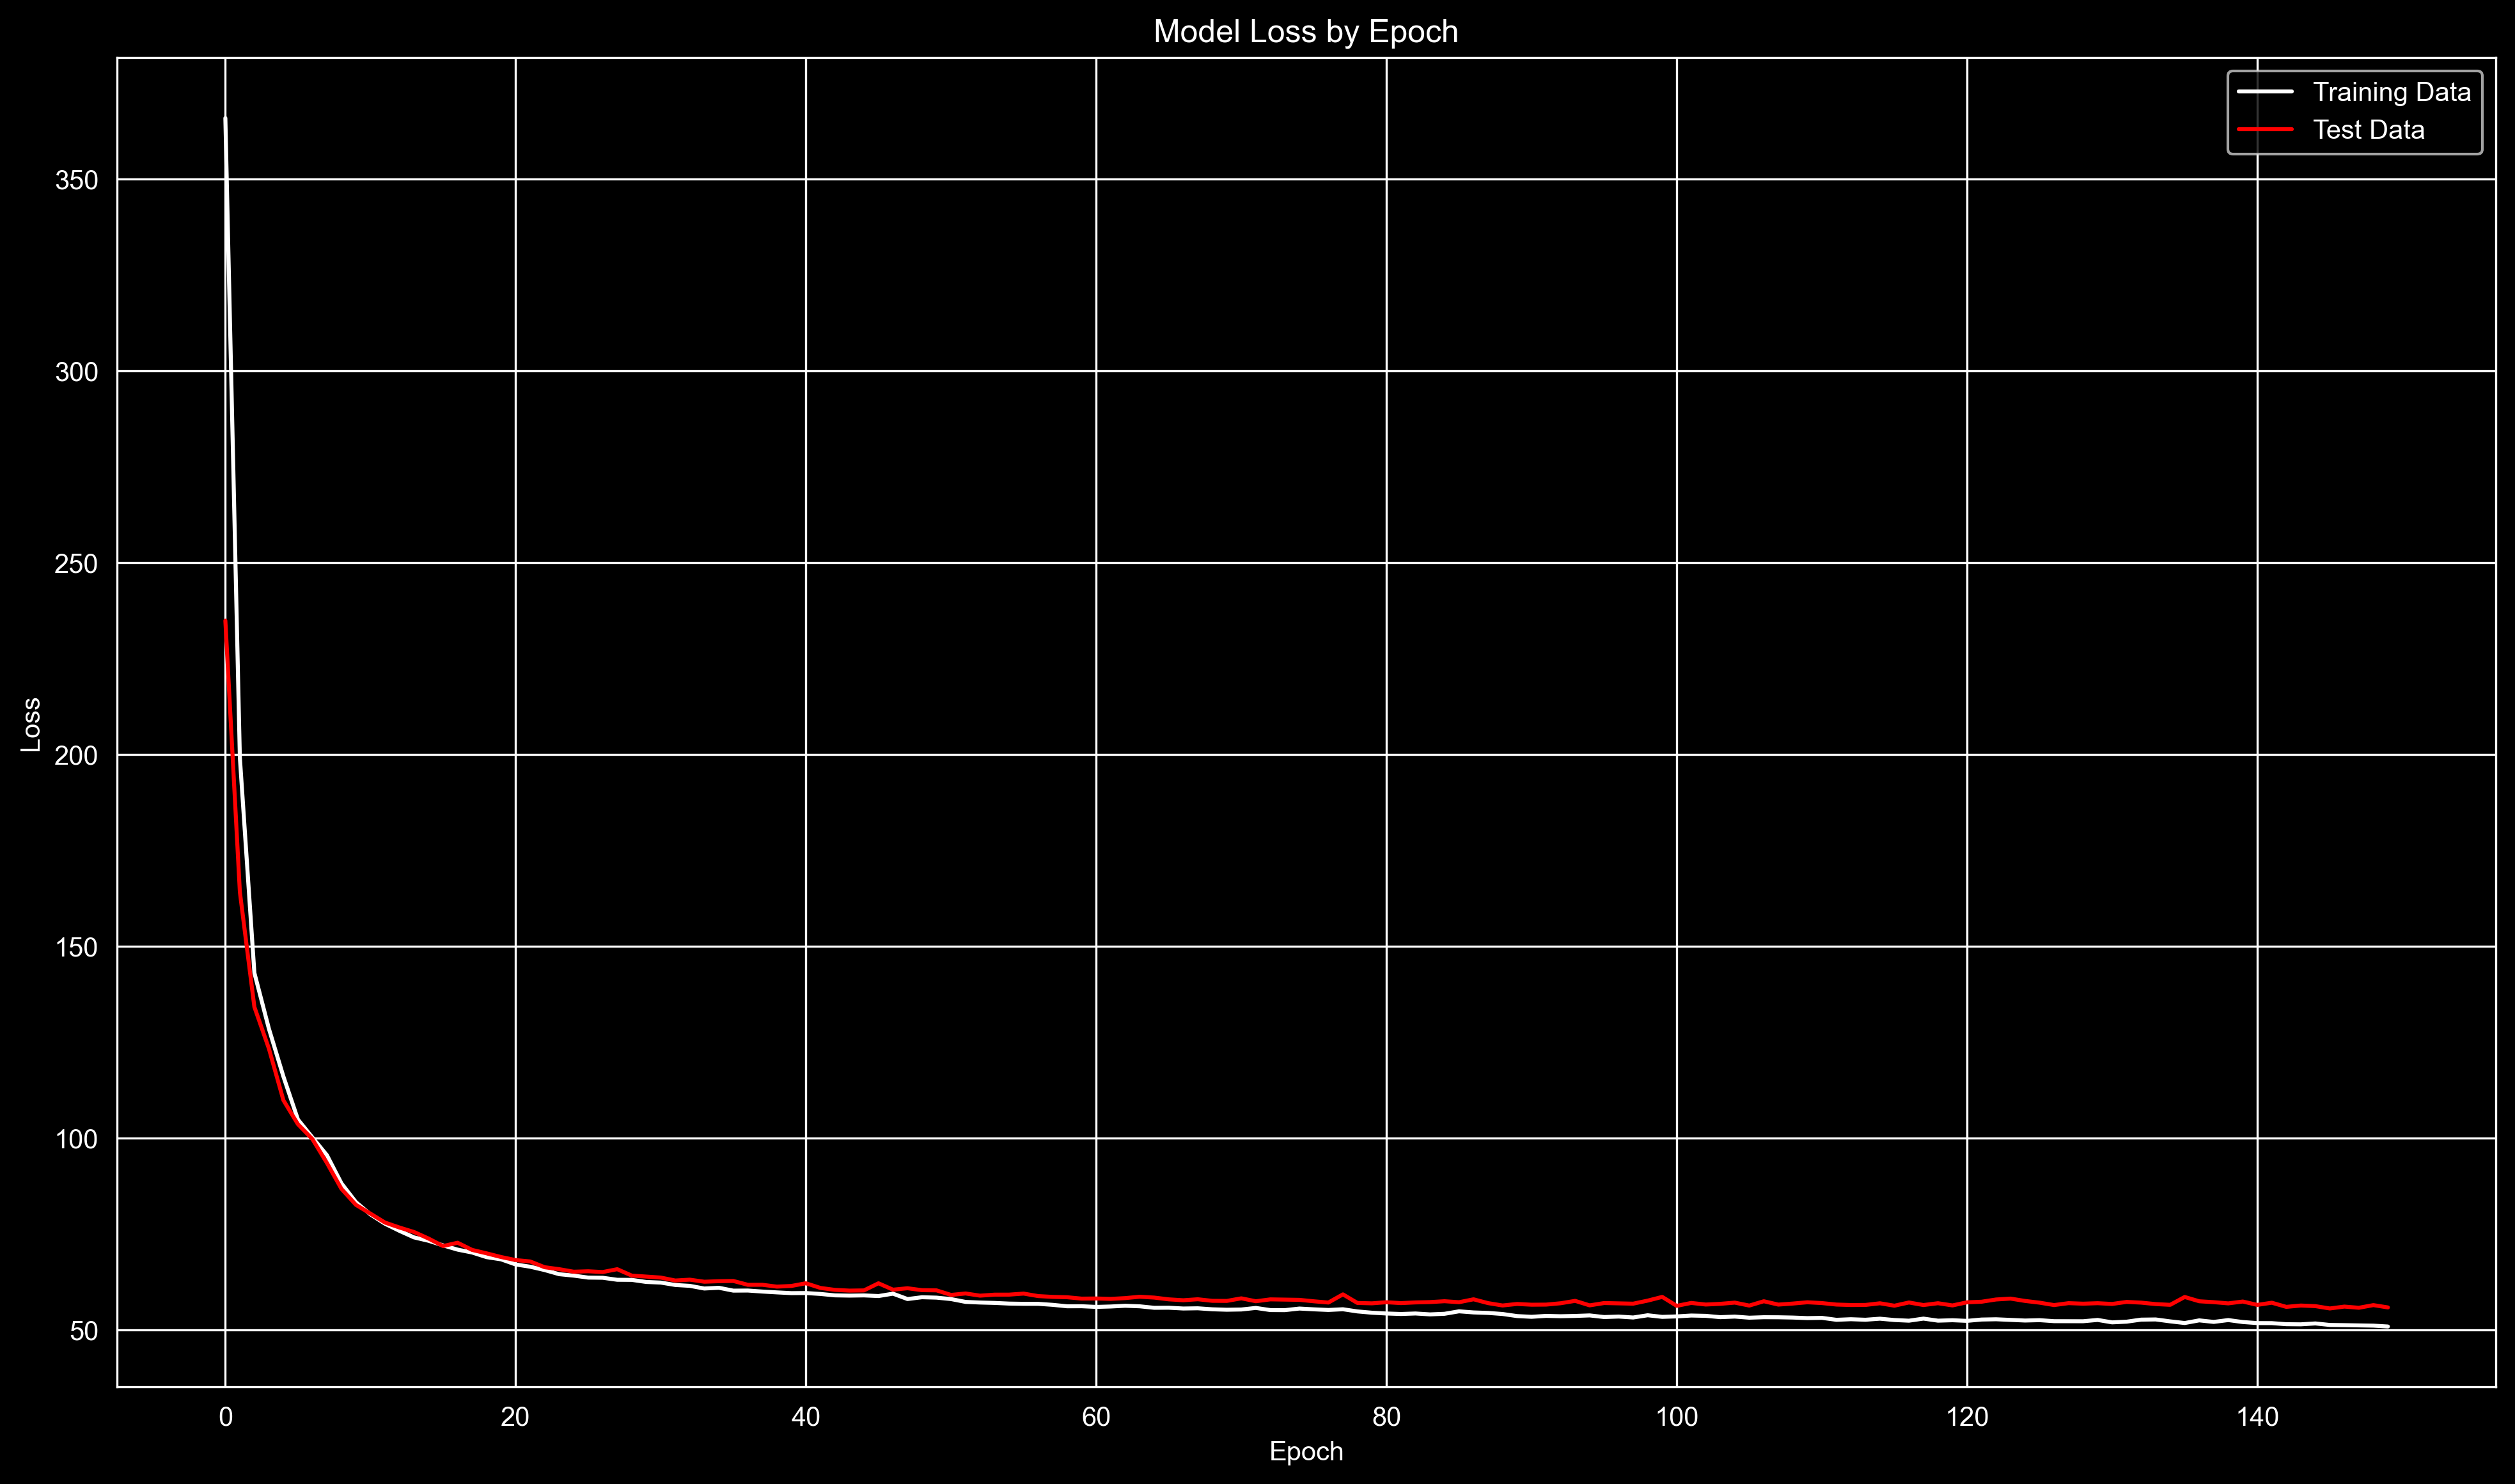

In [5]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
utils.plot_losses(training_loss, validation_loss)

## Cross validation

In [9]:
cross_validator = CrossValidator(vae=vae,filepath=filepath,cluster_number=cluster_number,n_runs=3)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

Epoch 1/150
23/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 428.0597

/Users/quentin.nicolas/Desktop/CodeEmma/CodeForEarth/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 372.1535 - val_loss: 237.1185
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 202.5047 - val_loss: 168.9992
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 148.4600 - val_loss: 135.6061
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 126.9871 - val_loss: 120.4192
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 114.2729 - val_loss: 109.5801
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 103.5288 - val_loss: 102.1829
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 98.6989 - val_loss: 97.0570
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92.0782 - val_loss: 90.0128
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 88.1940 - val_loss: 88.7295
Epoch 10/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 85.1461 - val_loss: 85.1183
Epoch 11/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 81.9396 - val_loss: 82.5371
Epoch 12/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0

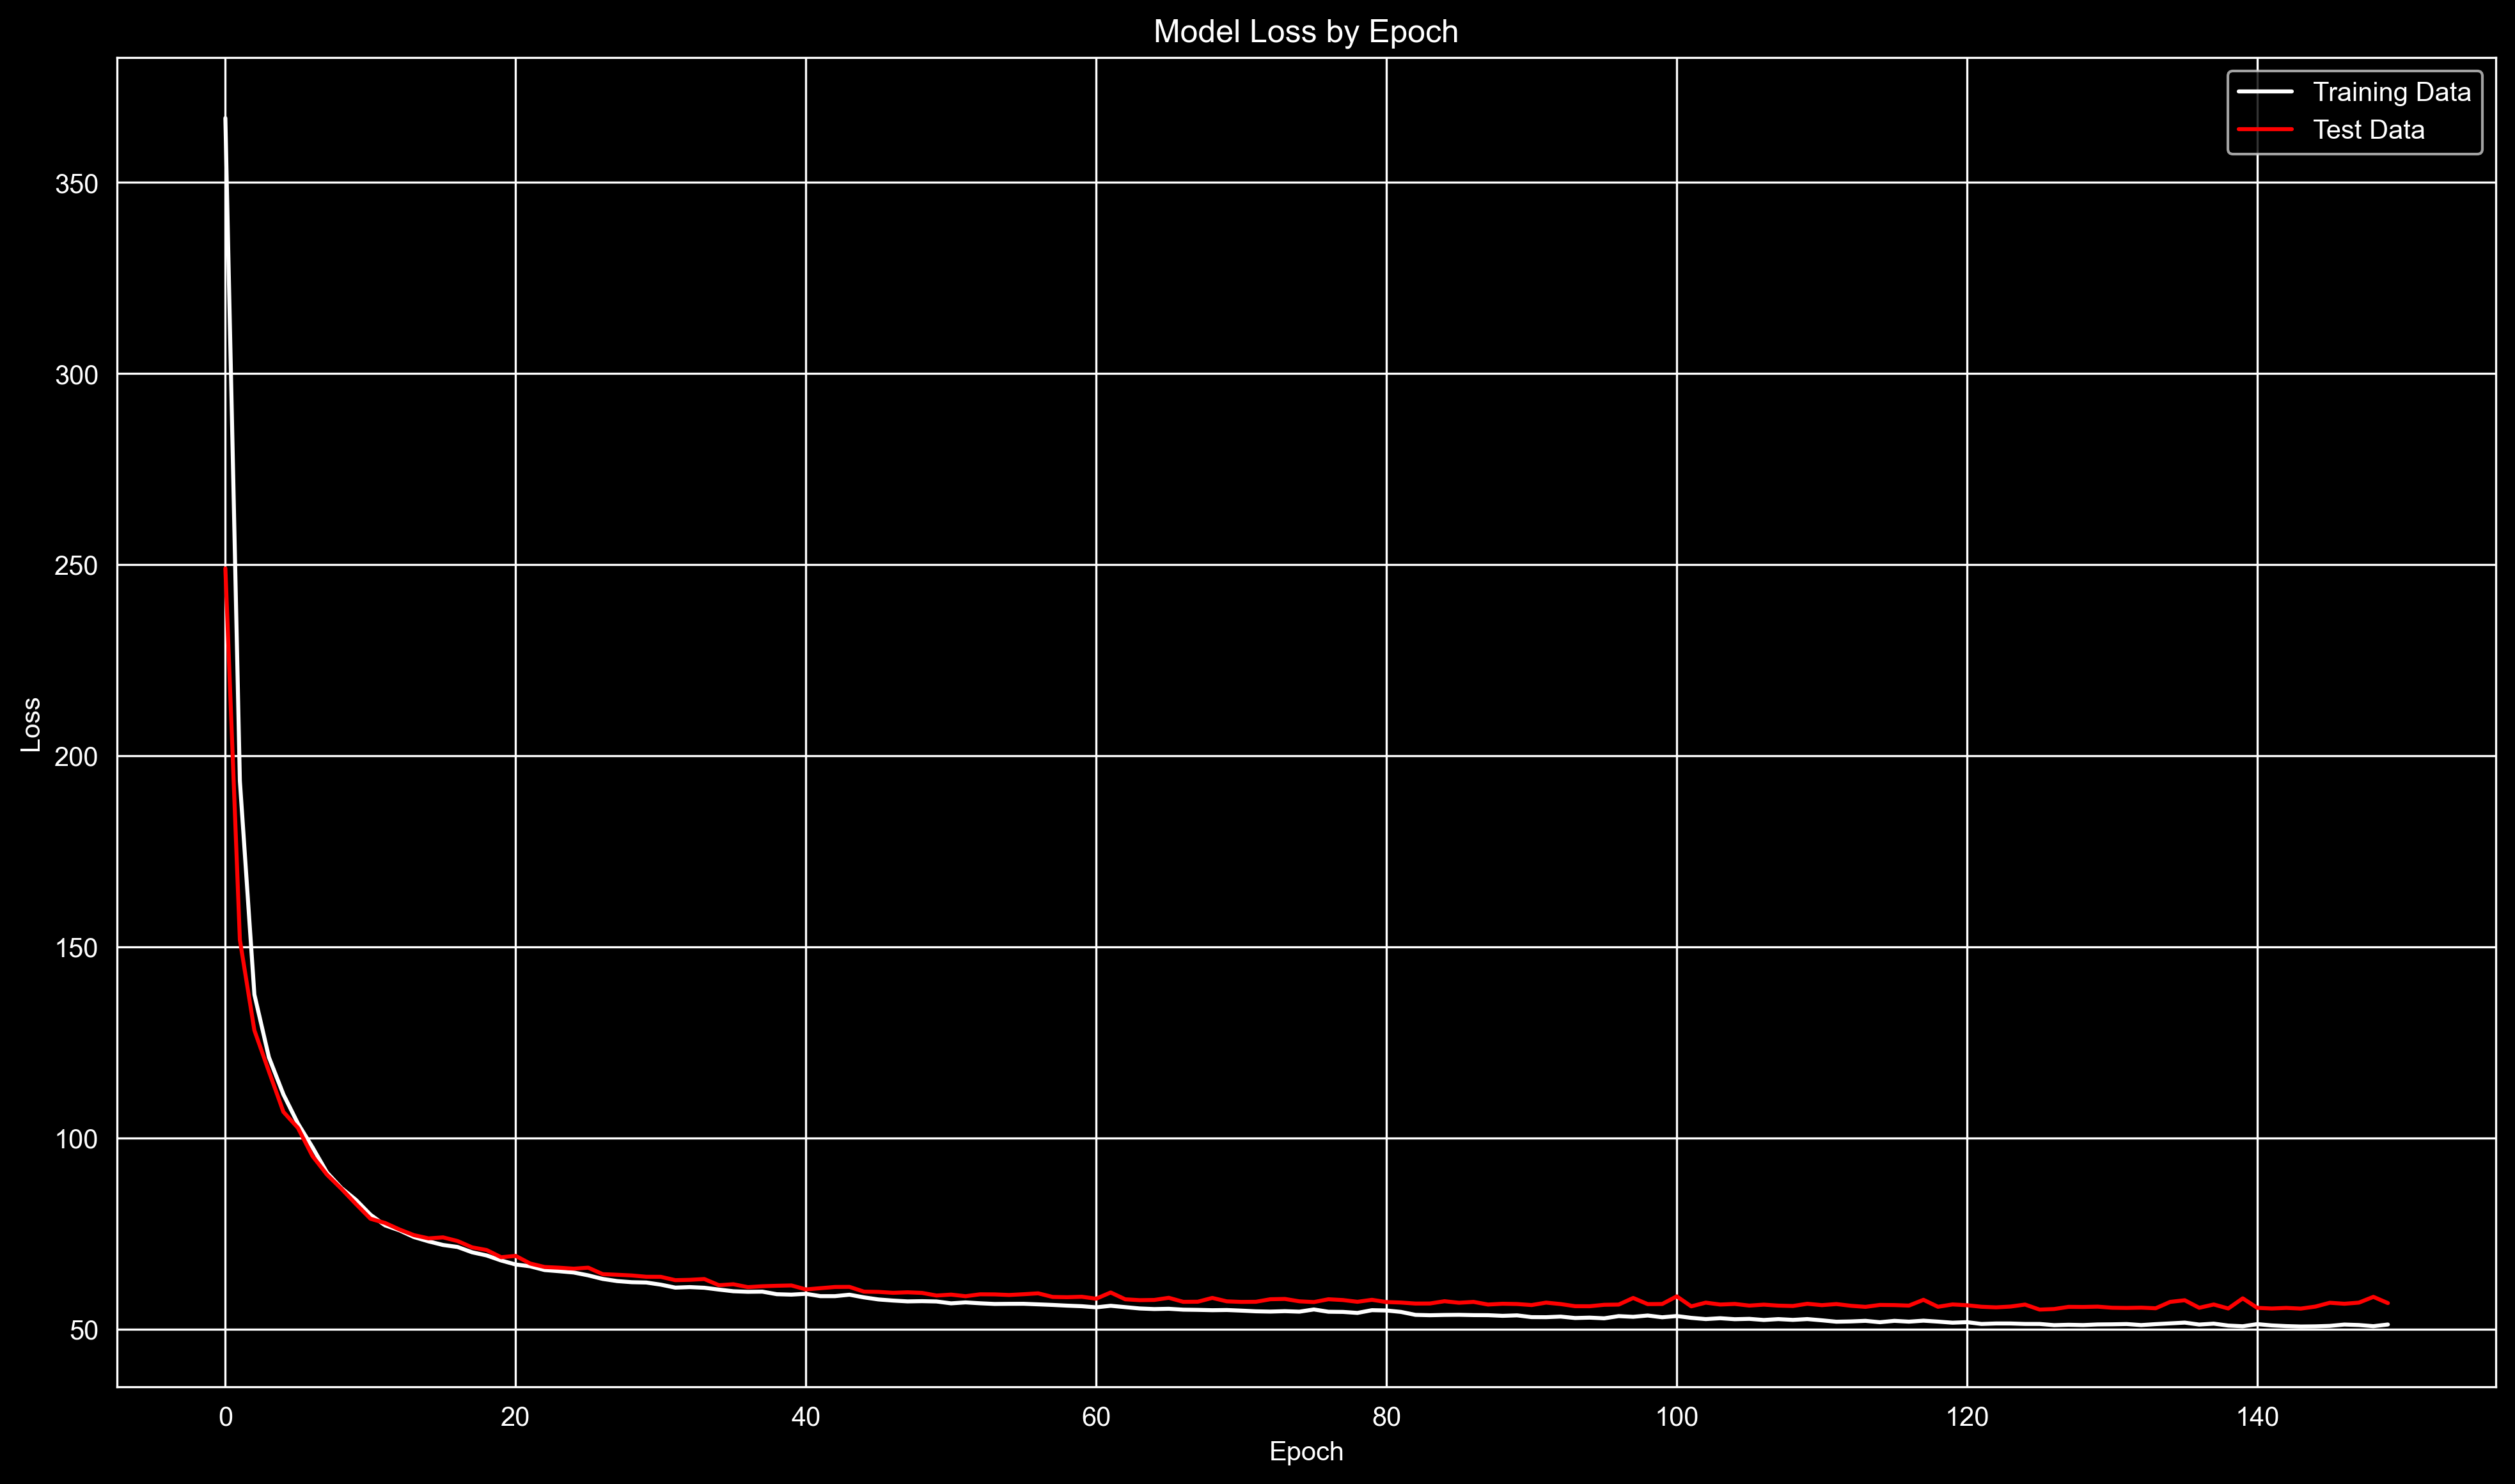

In [11]:
number = 1

training_loss = histories[number].history['loss']
validation_loss = histories[number].history['val_loss']
utils.plot_losses(training_loss, validation_loss)